<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/K_Modes_con_datos_de_comportamiento_de_compras_clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

Se utilizan datos relacionados con aspectos y características asociadas al comportamiento de compras de clientes.

Las variables describen características comerciales y de comportamiento, tales como el segmento al que pertenece el cliente, el canal por el cual realiza sus compras, la región donde se ubica, el tipo de producto que consume con mayor frecuencia, su frecuencia de compra, su nivel de satisfacción, el método de pago utilizado y su respuesta ante promociones, entre otros.

Las variables:

* *cliente*  es el identificador único del cliente, no participa en el modelo,
* *segmento* es el segmento del cliente o clasificación comercial del cliente, por ejemplo: *Premium*, *Frecuente*, *Promocional*, *Ocasional*, *Nuevo* o *Riesgo*,
* *canal* define el canal principal de compra como: *App*, *Web*, *Tienda* o *Teléfono*,
* *region* es la región geográfica o comercial donde se ubica el cliente: *Occidente*, *Sur*, *Centro* o *Norte*,
* *producto* es el tipo o categoría de producto que el cliente consume con mayor frecuencia: *Servicios*,   *Moda*, *Alimentos*, *Tecnologia* u *Hogar*,
* *frecuencia* es el nivel de frecuencia con que el cliente compra: *Baja*, *Media* o *Alta*,
* *satisfaccion* es el grado de satisfacción reportado o estimado del cliente: *Bajo*, *Medio* o *Alto*,
* *pago* es el método de pago utilizado con mayor frecuencia: *Digital*, *Efectivo*, *Transferencia* o *Tarjeta*,                                             
* *respromocion* es el nivel de respuesta del cliente ante promociones: *Baja*, *Media* o *Alta*,     
* *perfil* es la variable de referencia generada para simular perfiles latentes; no se utiliza en el modelo *K-Modes*.

Los datos se encuentra en el servicio *github.com* https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_clientes_kmodes_empresarial.csv .


El caso de estudio puede verse en el portal de google collab en https://colab.research.google.com/drive/1XhQsEUUv6f4u9P5dQoBEk_EfqVmnKGqq?usp=sharing .

De igual forma, el caso de estudio puede encontrarse para su descarga y visualización en el portal de *github.com* en el espacio del autor https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/K_Modes_con_datos_de_comportamiento_de_compras_clientes.ipynb  .

Las funciones para la ejecución adecuada de este caso de estudio se encuentran en servicio *github.com* en el espacio https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20K%20Modes%20datos%20comportamientos%20clientes.py .

# Objetivo

Construir y evaluar modelo *K-Modes* con tres y cuatro grupos a partir de datos de comportamiento de compras de clientes.



# Descripción

## Cargar librerías


In [8]:
# !pip install kmodes

In [9]:
import numpy as np   # Para estructuras de datos
import pandas as pd  # Cargar conjuntos de datos
import matplotlib.pyplot as plt # Visualizar
import math # Funciones matemáticas
import itertools # Para iteraciones o ciclos
import seaborn as sns   # Gráficos

from kmodes.kmodes import KModes # K Modes
from matplotlib.ticker import PercentFormatter # Graficos depurados



## Cargar funciones


In [10]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20K%20Modes%20datos%20comportamientos%20clientes.py"
import requests

exec(requests.get(url).text)

## Cargar datos


In [11]:
datos = f_cargar_datos("https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/datos_clientes_kmodes_empresarial.csv")
# edad	experiencia	entrenamiento	resistencia	fuerza	velocidad	agilidad	flexibilidad	concentracion	disciplina	motivacion	manejo_estres	promedio	competitividad
datos = datos[["segmento", "canal", "region", "producto",
               "frecuencia" ,"satisfaccion", "pago", "respromocion"]]

f_visualizar_head_tail_reducido(datos)

,segmento,canal,region,producto,...,frecuencia,satisfaccion,pago,respromocion
0,Premium,Web,Occidente,Servicios,...,Media,Alta,Digital,Media
1,Promocional,Web,Sur,Moda,...,Media,Media,Digital,Alta
2,Riesgo,Tienda,Occidente,Alimentos,...,Baja,Media,Efectivo,Baja
3,Frecuente,App,Centro,Tecnologia,...,Alta,Alta,Transferencia,Media
4,Promocional,App,Sur,Tecnologia,...,Alta,Media,Digital,Alta
5,Riesgo,Telefono,Occidente,Moda,...,Media,Media,Tarjeta,Baja
6,...,...,...,...,...,...,...,...,...
7,Frecuente,Web,Norte,Servicios,...,Media,Alta,Digital,Media
8,Ocasional,App,Centro,Moda,...,Media,Media,Efectivo,Media
9,Premium,Tienda,Sur,Tecnologia,...,Alta,Alta,Tarjeta,Alta


# Desarrollo


## Las variables para el modelo K-Modes


In [12]:
variables = ["segmento", "canal", "region", "producto",
             "frecuencia" ,"satisfaccion", "pago", "respromocion"]

## K Modes K=3

In [13]:
modelo_KModesK3 = KModes(
    n_clusters=3,
    init="Huang",
    n_init=25,
    max_iter=100,
    random_state=2026
)

modelo_KModesK3.fit(datos)

KModes(init='Huang', n_clusters=3, n_init=25, random_state=2026)

### Modas para K=3

In [14]:
modas_finalesK3 = pd.DataFrame(modelo_KModesK3.cluster_centroids_, columns=variables)

modas_finalesK3.insert(0, "cluster", range(1, modelo_KModesK3.n_clusters + 1))

modas_finalesK3



,cluster,segmento,canal,region,producto,frecuencia,satisfaccion,pago,respromocion
0,1,Ocasional,Tienda,Sur,Alimentos,Baja,Media,Efectivo,Baja
1,2,Frecuente,App,Norte,Tecnologia,Alta,Alta,Tarjeta,Alta
2,3,Promocional,Web,Centro,Hogar,Media,Media,Digital,Alta


### Visualización de clúster por variables con K=3


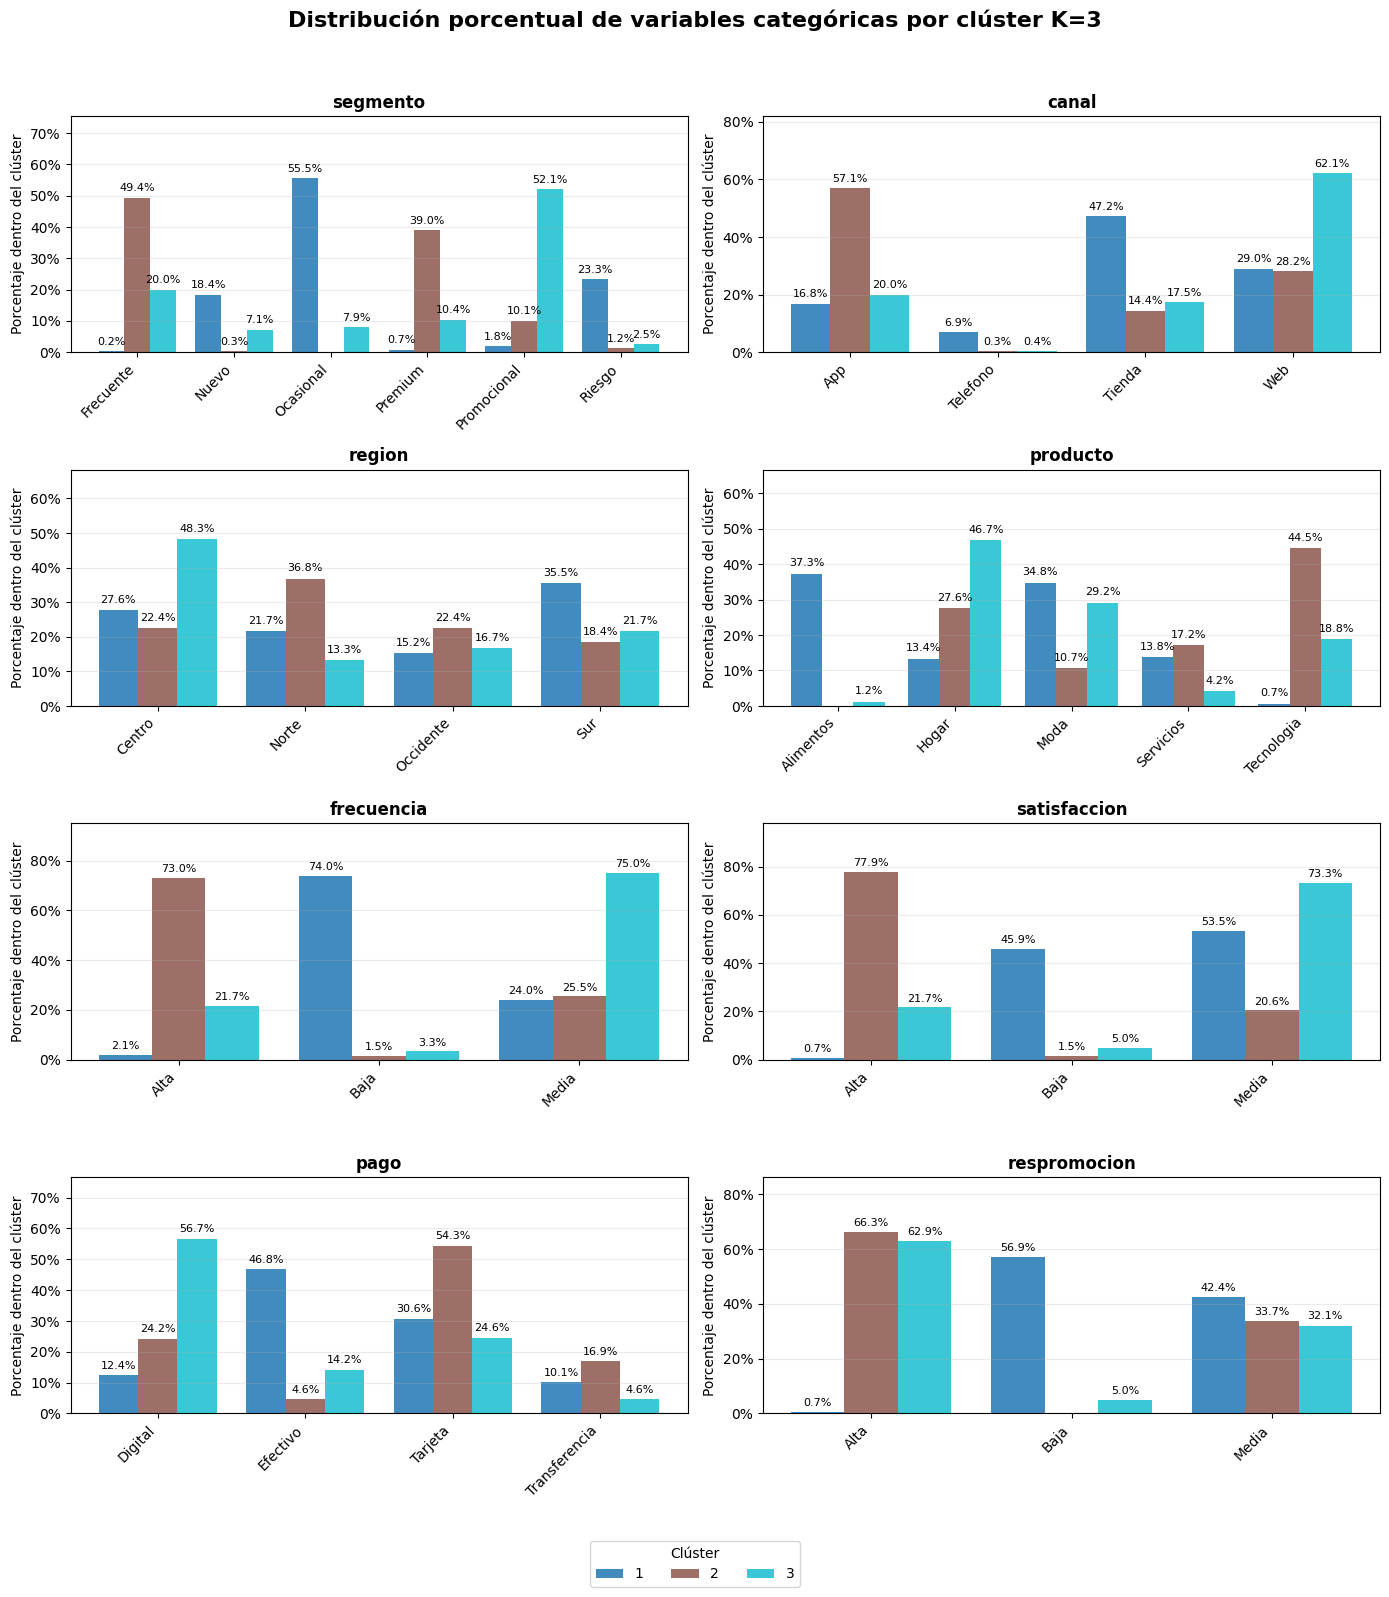

In [15]:
datos_visual = datos.copy()
cluster3 = modelo_KModesK3.labels_ + 1
datos_visual["cluster_KModesK3"] = cluster3

resultado_visual = f_visualizar_clusters_categoricos(
    datos=datos_visual,
    variable_cluster="cluster_KModesK3",
    variables=variables,
    ncol=2,
    titulo="Distribución porcentual de variables categóricas por clúster K=3",
    posicion="dodge",
    mostrar_etiquetas=True,
    rotar_etiquetas=True
)

## K Modes K=4

In [16]:
modelo_KModesK4 = KModes(
    n_clusters=4,
    init="Huang",
    n_init=25,
    max_iter=100,
    random_state=2026
)

modelo_KModesK4.fit(datos)


KModes(init='Huang', n_clusters=4, n_init=25, random_state=2026)

In [17]:
modas_finalesK4 = pd.DataFrame(modelo_KModesK4.cluster_centroids_, columns=variables)

modas_finalesK4.insert(0, "cluster", range(1, modelo_KModesK4.n_clusters + 1))

modas_finalesK4

,cluster,segmento,canal,region,producto,frecuencia,satisfaccion,pago,respromocion
0,1,Promocional,Web,Norte,Hogar,Media,Media,Digital,Alta
1,2,Ocasional,Tienda,Sur,Moda,Baja,Media,Tarjeta,Media
2,3,Frecuente,App,Centro,Tecnologia,Alta,Alta,Tarjeta,Alta
3,4,Riesgo,Tienda,Norte,Alimentos,Baja,Baja,Efectivo,Baja


### Modas para K=4

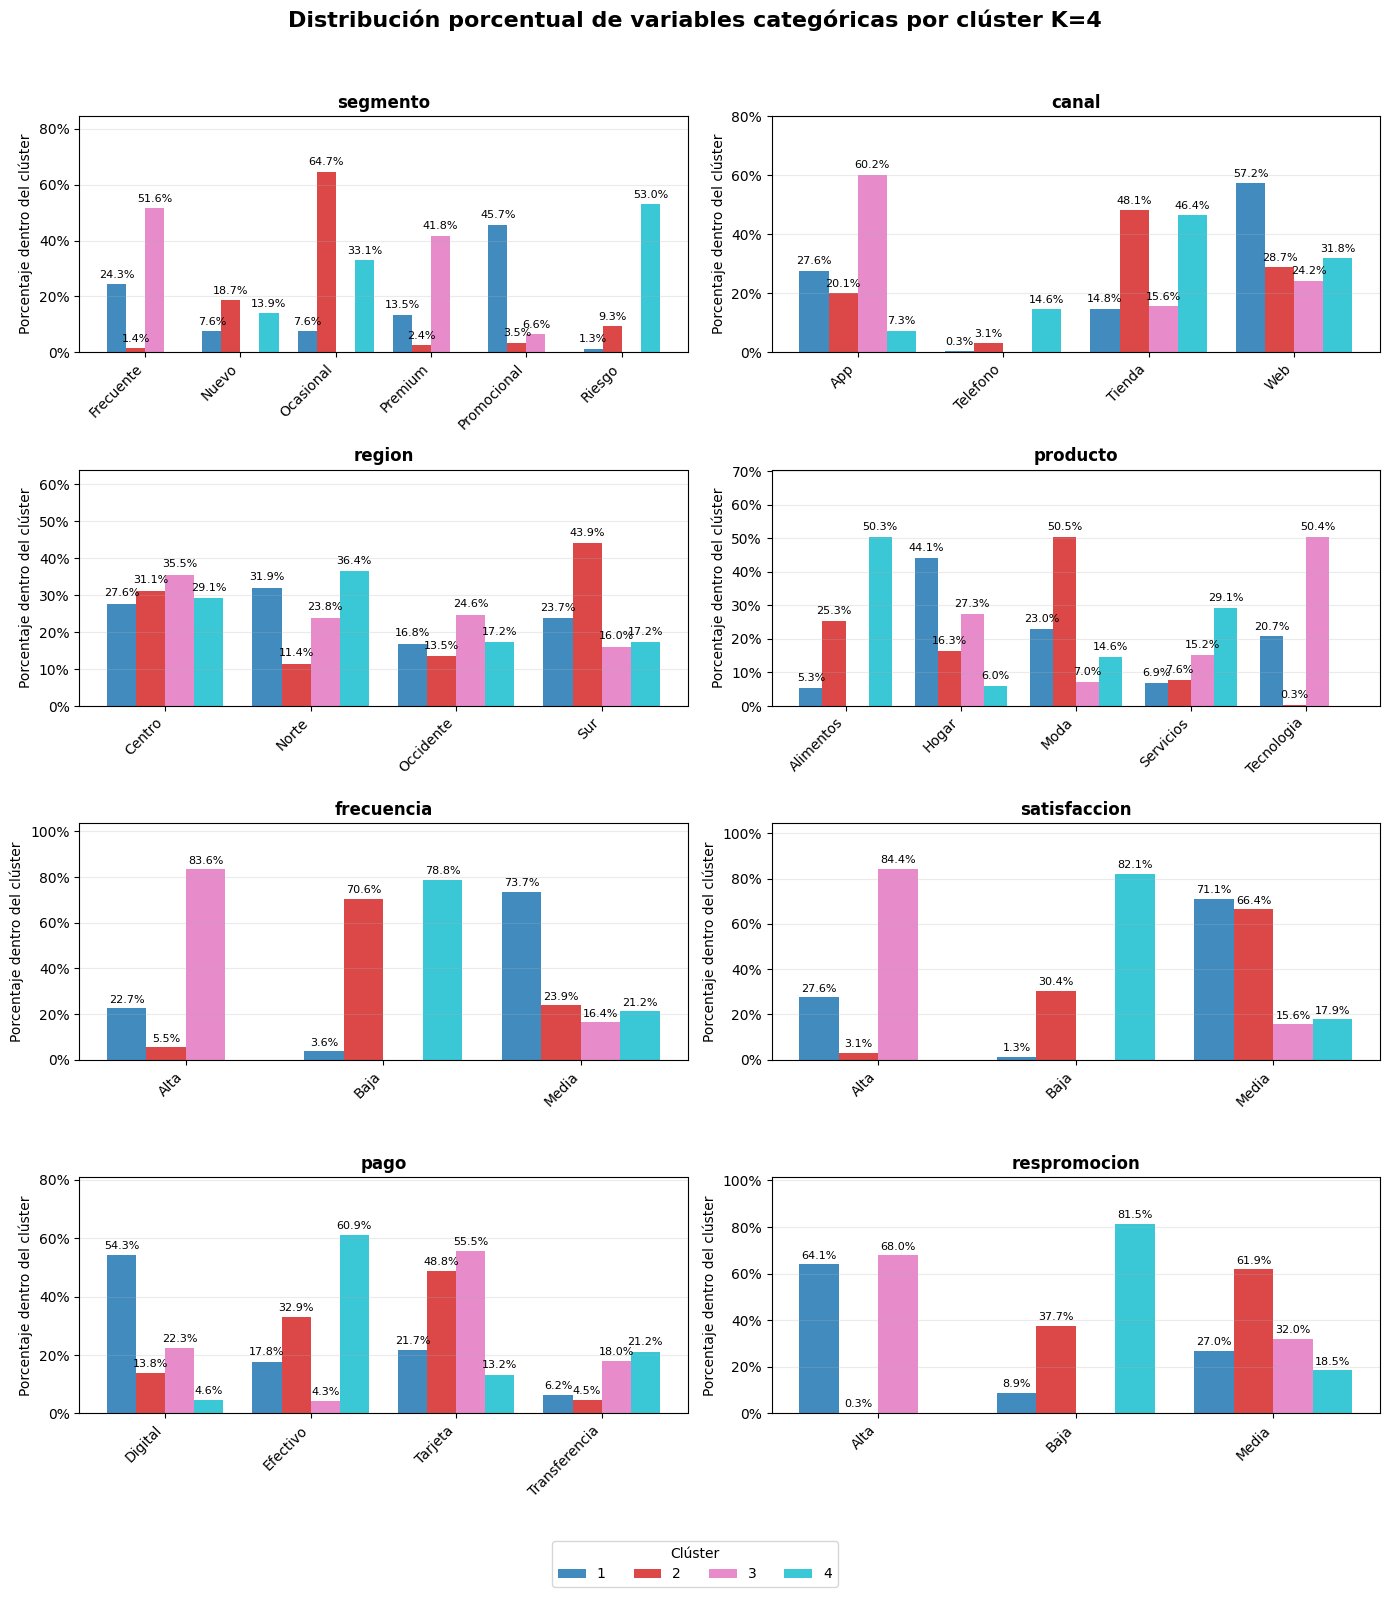

In [18]:
datos_visual = datos.copy()
cluster4 = modelo_KModesK4.labels_ + 1
datos_visual["cluster_KModesK4"] = cluster4

resultado_visual = f_visualizar_clusters_categoricos(
    datos=datos_visual,
    variable_cluster="cluster_KModesK4",
    variables=variables,
    ncol=2,
    titulo="Distribución porcentual de variables categóricas por clúster K=4",
    posicion="dodge",
    mostrar_etiquetas=True,
    rotar_etiquetas=True
)

## Evaluar costos e K=3 y K=4


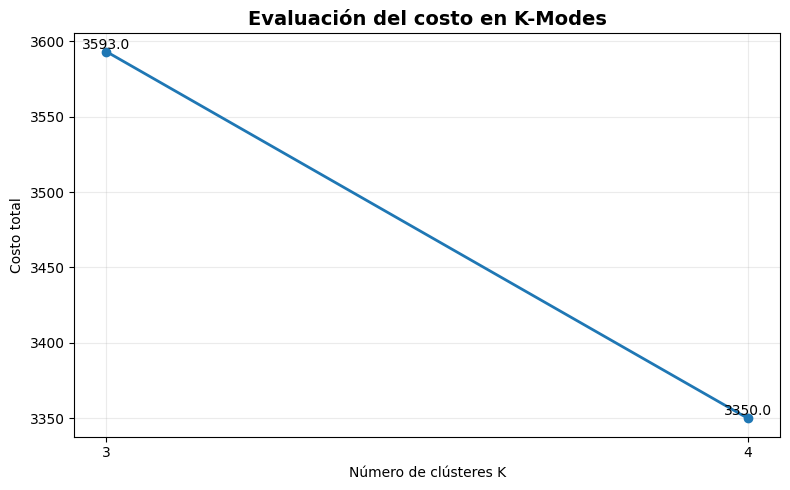

,modelo,k,n,costo_total,costo_promedio,reduccion_absoluta,reduccion_porcentual
0,K-Modes K=3,3,1000,3593.0,3.593,NaN,NaN
1,K-Modes K=4,4,1000,3350.0,3.350,243.0,6.7632


In [19]:
resultado_costo = f_evaluar_costo_KModes(
    modelos=[
        modelo_KModesK3,
        modelo_KModesK4
    ],
    nombres_modelos=[
        "K-Modes K=3",
        "K-Modes K=4"
    ],
    graficar=True
)

resultado_costo["tabla_costos"]

# Interpretación del caso

Los resultados ofrecidos en el modelo *K-Modes* descritos con *Python*, ofrece resultados similares a los que se presentan en *R*.

Al observar las modas generdas en *R* y *Pyhton* estas no son exactamente, esto debe suponerse a el mecanismo interno de cada función, a la inicialización de las modas, entre otros aspectos. Sin embargo, aunque no coinciden exactamente las modas, los modelos sí están encontrando una estructura similar y parecida.

El modelo *K-Modes* con *K=4* reduce el costo de desimilitud en un *6,76%* similar a la reducc[pon de costo que se obtiene en *R* lo que supone una estructura similar.

Los modelos de *clustering* como el *K-Modes* y otros se prestan para que se pueda experimentar con la cantidad de clústers a formar, aquí se usó *3* y *4* clúster pero, pudieron haber sido *2* o *5*; esto es precisamente lo que puede permitirse el científico de datos el poder manipular la cantidad de clúster y con ello, buscar una adecuada interpretación y comprensión de los grupso formados a partir de los datos.






